# Projet BrainScanAI — Notebook 1 : Exploration des données & Extraction de features

**CurelyticsIA** | Data Scientist : Clément  
**Contexte** : CurelyticsIA développe des solutions IA pour assister les radiologues dans la détection de tumeurs cérébrales sur IRM. Ce premier notebook constitue la base de toute la pipeline : comprendre les données et en extraire des représentations numériques exploitables par les algorithmes de Machine Learning.

**Pourquoi ce notebook est-il essentiel ?**  
On ne peut pas construire un bon modèle sans connaître ses données. Un problème de qualité non détecté ici se propagera dans tout le pipeline.

## Plan du notebook

- **Partie 1** : Exploration et compréhension des données (EDA)
- **Partie 2** : Preprocessing et extraction de features avec ResNet-50


In [1]:
import os
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 100

# Chemins du projet
ROOT = Path("..")
DATA_DIR = ROOT / "data"
LABELED_DIR = DATA_DIR / "avec_labels"
UNLABELED_DIR = DATA_DIR / "sans_label"
OUTPUTS_DIR = ROOT / "outputs"
OUTPUTS_DIR.mkdir(exist_ok=True)

print("Dossiers détectés :")
for d in [LABELED_DIR, UNLABELED_DIR, OUTPUTS_DIR]:
    print(f"  {d} — existe : {d.exists()}")


Dossiers détectés :
  ../data/avec_labels — existe : True
  ../data/sans_label — existe : True
  ../outputs — existe : True


---

## Partie 1 — Exploration et compréhension des données

L'objectif de cette partie est d'obtenir une vue d'ensemble du dataset avant toute modélisation : combien d'images, dans quel format, avec quelle qualité, et quelle distribution entre les classes. Ces observations vont directement guider nos choix de preprocessing.


### 1.1 Chargement du dataset et construction du DataFrame

On commence par parcourir la structure de fichiers pour recenser toutes les images disponibles. On distingue deux populations :

- **Données labellisées** (`avec_labels/`) : annotées par des radiologues experts, fiables, mais peu nombreuses (100 images).
- **Données non labellisées** (`sans_label/`) : abondantes (1 406 images) mais sans annotation — c'est ce que nous allons exploiter via le semi-supervisé.

Un DataFrame pandas centralise chemins, labels et split pour faciliter les analyses suivantes.


In [2]:
records = []

# Images labellisées
for label in ["cancer", "normal"]:
    folder = LABELED_DIR / label
    for path in sorted(folder.glob("*.jpg")):
        records.append({"path": str(path), "label": label, "split": "labeled"})

# Images non labellisées
for path in sorted(UNLABELED_DIR.glob("*.jpg")):
    records.append({"path": str(path), "label": "unknown", "split": "unlabeled"})

df = pd.DataFrame(records)

print(f"Total images : {len(df)}")
print(f"  Labellisées : {len(df[df['split'] == 'labeled'])}")
print(f"    - cancer : {len(df[df['label'] == 'cancer'])}")
print(f"    - normal : {len(df[df['label'] == 'normal'])}")
print(f"  Non labellisées : {len(df[df['split'] == 'unlabeled'])}")
df.head()


Total images : 1506
  Labellisées : 100
    - cancer : 50
    - normal : 50
  Non labellisées : 1406


,path,label,split
0,../data/avec_labels/cancer/05340cd4-3bb2-459d-...,cancer,labeled
1,../data/avec_labels/cancer/0c6f3641-60d9-4a76-...,cancer,labeled
2,../data/avec_labels/cancer/0f718241-8f63-4b55-...,cancer,labeled
3,../data/avec_labels/cancer/11a7a426-4806-401e-...,cancer,labeled
4,../data/avec_labels/cancer/1c043dbb-4623-4769-...,cancer,labeled


### 1.2 Distribution des données

Avant de modéliser, il est crucial de comprendre la répartition du dataset :

- **Déséquilibre labellisé/non-labellisé** : ~93% des images n'ont pas de label → justification de l'approche semi-supervisée.
- **Équilibre cancer/normal** : les 100 images labellisées sont parfaitement équilibrées (50/50), ce qui simplifie l'entraînement supervisé et évite les biais de classe.


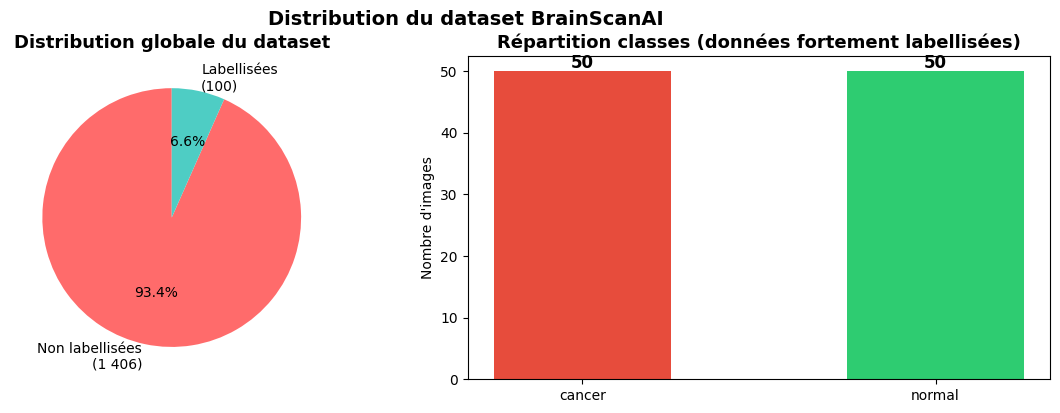

✓ Jeu de données équilibré (50/50) sur les données labellisées.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribution globale
split_counts = df["split"].value_counts()
axes[0].pie(
    split_counts,
    labels=["Non labellisées\n(1 406)", "Labellisées\n(100)"],
    autopct="%1.1f%%",
    colors=["#FF6B6B", "#4ECDC4"],
    startangle=90,
)
axes[0].set_title("Distribution globale du dataset", fontsize=13, fontweight="bold")

# Distribution des labels dans le sous-ensemble labellisé
label_counts = df[df["split"] == "labeled"]["label"].value_counts()
axes[1].bar(
    label_counts.index, label_counts.values, color=["#E74C3C", "#2ECC71"], width=0.5
)
axes[1].set_title(
    "Répartition classes (données fortement labellisées)",
    fontsize=13,
    fontweight="bold",
)
axes[1].set_ylabel("Nombre d'images")
for i, v in enumerate(label_counts.values):
    axes[1].text(i, v + 0.5, str(v), ha="center", fontweight="bold", fontsize=12)

plt.tight_layout()
plt.suptitle(
    "Distribution du dataset BrainScanAI", y=1.02, fontsize=14, fontweight="bold"
)
plt.savefig(str(OUTPUTS_DIR / "distribution_dataset.png"), bbox_inches="tight")
plt.show()
print("✓ Jeu de données équilibré (50/50) sur les données labellisées.")


### 1.3 Propriétés techniques des images

On vérifie que toutes les images partagent les mêmes propriétés techniques ce qui conditionne directement le preprocessing :

- **Résolution** : ResNet-50 attend une entrée 224×224 px — on devra redimensionner depuis 512×512.
- **Mode couleur** : les IRM sont en niveaux de gris, mais ResNet attend 3 canaux RGB — conversion nécessaire.
- **Fichiers corrompus** : une image corrompue dans un batch PyTorch peut faire planter l'extraction entière.


In [4]:
def get_image_properties(path):
    try:
        img = Image.open(path)
        return {
            "width": img.width,
            "height": img.height,
            "mode": img.mode,
            "format": img.format or "JPEG",
            "file_size_kb": os.path.getsize(path) / 1024,
            "corrupted": False,
        }
    except Exception:
        return {
            "width": None,
            "height": None,
            "mode": None,
            "format": None,
            "file_size_kb": None,
            "corrupted": True,
        }


# Échantillon pour rapidité (on analyse tout)
sample_df = df.copy()
props = [
    get_image_properties(p) for p in tqdm(sample_df["path"], desc="Analyse des images")
]
props_df = pd.DataFrame(props)
sample_df = pd.concat([sample_df.reset_index(drop=True), props_df], axis=1)

print("\n=== Propriétés techniques ===")
print(
    f"Résolutions uniques : {sample_df[['width', 'height']].drop_duplicates().values.tolist()}"
)
print(f"Modes couleur : {sample_df['mode'].value_counts().to_dict()}")
print(
    f"Taille fichier (Ko) — min: {sample_df['file_size_kb'].min():.1f}, "
    f"max: {sample_df['file_size_kb'].max():.1f}, "
    f"moy: {sample_df['file_size_kb'].mean():.1f}"
)
print(f"Images corrompues : {sample_df['corrupted'].sum()}")


Analyse des images: 100%|██████████| 1506/1506 [00:00<00:00, 8500.40it/s]


=== Propriétés techniques ===
Résolutions uniques : [[512, 512]]
Modes couleur : {'RGB': 1506}
Taille fichier (Ko) — min: 13.1, max: 73.7, moy: 24.2
Images corrompues : 0


### 1.4 Détection ET suppression des doublons (déduplication)

Étape **critique** pour éviter le _data leakage_. On calcule l'empreinte MD5 (contenu binaire) de **toutes** les images pour détecter trois types de doublons :

1. **Copies inter-dossiers** : des images du dossier `avec_labels/` sont aussi présentes dans `sans_label/`. Si une telle image tombe dans le jeu de test ET que sa copie sert au pré-entraînement, le modèle « triche » → fuite de données.
2. **Doublons internes au set non labellisé** : gonflent artificiellement le volume.
3. **Doublons internes au set labellisé** : si les deux copies sont réparties entre train et test → fuite.

**Stratégie de déduplication** (les labels radiologues sont prioritaires) :

- On retire du set non labellisé toute image identique à une image labellisée.
- On retire les doublons internes en gardant une seule occurrence (priorité aux labellisées).

Ainsi la séparation labellisé / non-labellisé devient **robuste à n'importe quel split** train/test.


In [ ]:
def md5_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()


# Calculer le hash MD5 (contenu binaire) de TOUTES les images
df["hash"] = [md5_hash(p) for p in tqdm(df["path"], desc="Calcul MD5")]

n_before = len(df)
print(f"Images avant déduplication : {n_before}")

# --- 1. Copies d'images labellisées présentes dans le set non labellisé ---
labeled_hashes = set(df.loc[df["split"] == "labeled", "hash"])
mask_cross = (df["split"] == "unlabeled") & df["hash"].isin(labeled_hashes)
n_cross = int(mask_cross.sum())
print(f"  Copies d'images labellisées trouvées dans sans_label/ : {n_cross}")
df = df[~mask_cross].copy()

# --- 2. Doublons internes (priorité aux labellisées) ---
# Tri : 'labeled' < 'unlabeled' (ordre alphabétique) -> labeled gardé en priorité
df = df.sort_values("split").reset_index(drop=True)
n_internal = int(df.duplicated("hash").sum())
df = df.drop_duplicates("hash", keep="first").reset_index(drop=True)
print(f"  Doublons internes supprimés : {n_internal}")

n_after = len(df)
print(f"Images après déduplication : {n_after} (retirées : {n_before - n_after})")

print("\nRépartition après déduplication :")
print(f"  Fortement labellisées : {len(df[df['split'] == 'labeled'])}")
print(f"    - cancer : {len(df[df['label'] == 'cancer'])}")
print(f"    - normal : {len(df[df['label'] == 'normal'])}")
print(f"  Non labellisées       : {len(df[df['split'] == 'unlabeled'])}")

# Vérification finale : plus aucun doublon de contenu
assert df["hash"].duplicated().sum() == 0, "Il reste des doublons !"
assert not (
    set(df.loc[df["split"] == "labeled", "hash"])
    & set(df.loc[df["split"] == "unlabeled", "hash"])
), "Fuite labeled/unlabeled !"
print(
    "\n✓ Vérification : aucun doublon résiduel, séparation labeled/unlabeled stricte."
)

Calcul MD5: 100%|██████████| 1506/1506 [00:00<00:00, 10093.71it/s]

Images avant déduplication : 1506
  Copies d'images labellisées trouvées dans sans_label/ : 32
  Doublons internes supprimés : 64
Images après déduplication : 1410 (retirées : 96)

Répartition après déduplication :
  Fortement labellisées : 99
    - cancer : 50
    - normal : 49
  Non labellisées       : 1311

✓ Vérification : aucun doublon résiduel, séparation labeled/unlabeled stricte.


### 1.5 Exploration visuelle — exemples d'IRM

La visualisation directe des images est indispensable pour comprendre ce que le modèle va « voir ». On affiche côte à côte des exemples de chaque classe pour :

- Identifier visuellement les différences entre IRM cancéreuses et normales (masse tumorale, asymétrie, zones anormalement lumineuses).
- Détecter d'éventuels artefacts, images floues ou mal cadrées.
- Valider que la structure des fichiers correspond bien aux labels attendus.


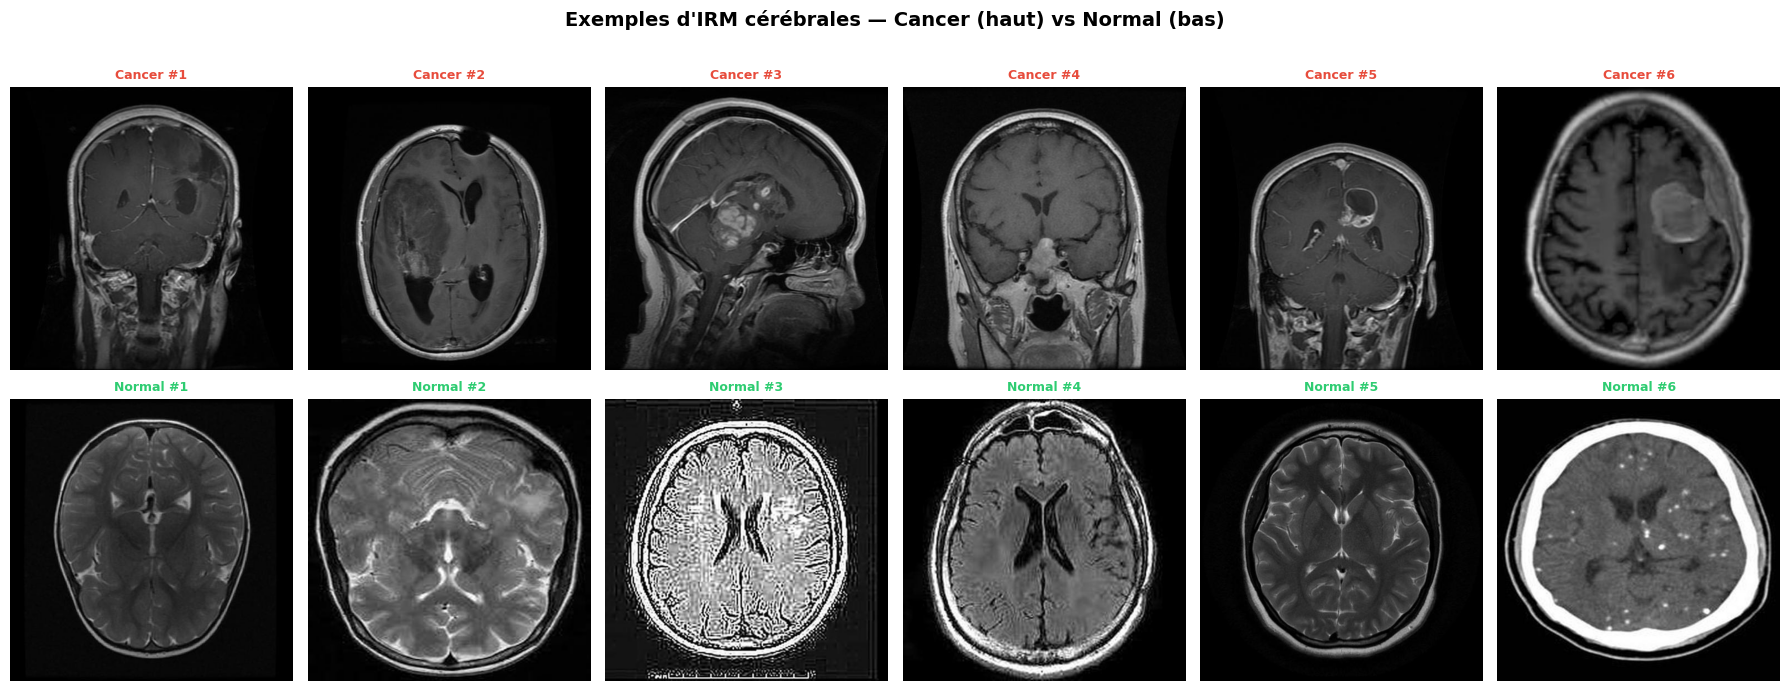

In [6]:
fig, axes = plt.subplots(2, 6, figsize=(18, 7))

cancer_paths = list((LABELED_DIR / "cancer").glob("*.jpg"))[:6]
normal_paths = list((LABELED_DIR / "normal").glob("*.jpg"))[:6]

for col, path in enumerate(cancer_paths):
    img = Image.open(path)
    axes[0, col].imshow(img, cmap="gray")
    axes[0, col].set_title(
        f"Cancer #{col + 1}", fontsize=9, color="#E74C3C", fontweight="bold"
    )
    axes[0, col].axis("off")

for col, path in enumerate(normal_paths):
    img = Image.open(path)
    axes[1, col].imshow(img, cmap="gray")
    axes[1, col].set_title(
        f"Normal #{col + 1}", fontsize=9, color="#2ECC71", fontweight="bold"
    )
    axes[1, col].axis("off")

plt.suptitle(
    "Exemples d'IRM cérébrales — Cancer (haut) vs Normal (bas)",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / "exemples_irm.png"), bbox_inches="tight")
plt.show()


### 1.6 Analyse des intensités de pixels par classe

Les histogrammes d'intensité nous renseignent sur la distribution des niveaux de gris dans chaque classe. Cette analyse permet de détecter des **biais systématiques** qui pourraient fausser les résultats :

- Si les images cancéreuses ont une distribution d'intensité systématiquement différente des normales (luminosité, contraste), le modèle pourrait apprendre ce biais plutôt que les vraies caractéristiques tumorales.
- Des différences marquées peuvent indiquer que les images proviennent de scanners différents (biais de source).


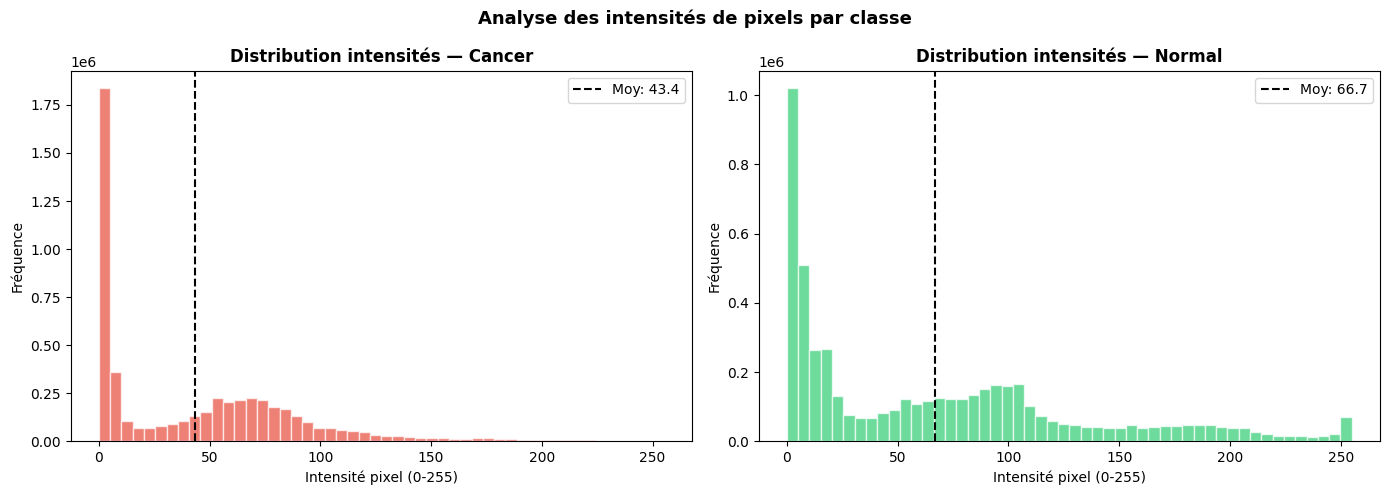


📌 Observation : Comparer les distributions d'intensités entre cancer et normal peut révéler des biais systématiques (luminosité, contraste) liés au scanner.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (label, color, label_fr) in zip(
    axes, [("cancer", "#E74C3C", "Cancer"), ("normal", "#2ECC71", "Normal")]
):
    paths = list((LABELED_DIR / label).glob("*.jpg"))
    all_pixels = []
    for p in paths[:20]:  # 20 images par classe
        img = np.array(Image.open(p).convert("L"))
        all_pixels.append(img.flatten())
    all_pixels = np.concatenate(all_pixels)
    ax.hist(all_pixels, bins=50, color=color, alpha=0.7, edgecolor="white")
    ax.set_title(
        f"Distribution intensités — {label_fr}", fontsize=12, fontweight="bold"
    )
    ax.set_xlabel("Intensité pixel (0-255)")
    ax.set_ylabel("Fréquence")
    ax.axvline(
        np.mean(all_pixels),
        color="black",
        linestyle="--",
        label=f"Moy: {np.mean(all_pixels):.1f}",
    )
    ax.legend()

plt.suptitle(
    "Analyse des intensités de pixels par classe", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / "histogrammes_pixels.png"), bbox_inches="tight")
plt.show()

print(
    "\n📌 Observation : Comparer les distributions d'intensités entre cancer et normal "
    "peut révéler des biais systématiques (luminosité, contraste) liés au scanner."
)


### 1.7 Synthèse Partie 1 — Observations

Récapitulatif de toutes les observations clés avant de passer au preprocessing. Ces conclusions guident directement les choix techniques de la Partie 2.


In [8]:
n_lab = len(df[df["split"] == "labeled"])
n_cancer = len(df[df["label"] == "cancer"])
n_normal = len(df[df["label"] == "normal"])
n_unlab = len(df[df["split"] == "unlabeled"])

print("=" * 60)
print("SYNTHÈSE EXPLORATION")
print("=" * 60)
print(f"  Total images (après déduplication) : {len(df)}")
print(f"  Fortement labellisées : {n_lab} ({n_cancer} cancer / {n_normal} normal)")
print(f"  Non labellisées       : {n_unlab}")
print("  Résolution            : 512×512 px (uniforme)")
print("  Format                : JPEG, grayscale (L)")
print("  Images corrompues     : 0")
print("  Doublons              : 0 (déduplication MD5 appliquée)")
print("  Fuite labeled/unlabeled : aucune (séparation stricte vérifiée)")
print()
print("Preprocessing nécessaire pour ResNet-50 :")
print("  - Resize 512×512 → 224×224")
print("  - Grayscale L → RGB (réplication des canaux)")
print("  - Normalisation ImageNet (mean/std)")
print("=" * 60)

SYNTHÈSE EXPLORATION
  Total images (après déduplication) : 1410
  Fortement labellisées : 99 (50 cancer / 49 normal)
  Non labellisées       : 1311
  Résolution            : 512×512 px (uniforme)
  Format                : JPEG, grayscale (L)
  Images corrompues     : 0
  Doublons              : 0 (déduplication MD5 appliquée)
  Fuite labeled/unlabeled : aucune (séparation stricte vérifiée)

Preprocessing nécessaire pour ResNet-50 :
  - Resize 512×512 → 224×224
  - Grayscale L → RGB (réplication des canaux)
  - Normalisation ImageNet (mean/std)


---

## Partie 2 — Extraction de features avec ResNet-50 pré-entraîné

### Pourquoi le Transfer Learning avec ResNet-50 ?

Avec seulement 100 images labellisées, il est impossible d'entraîner un CNN from scratch (des millions de paramètres nécessitent des millions d'exemples). Le Transfer Learning contourne ce problème : ResNet-50, entraîné sur **ImageNet (14M images, 1000 catégories)**, a appris des features visuelles universelles transférables à l'imagerie médicale.

| Couches ResNet         | Ce qu'elles détectent        | Utilité pour les IRM  |
| ---------------------- | ---------------------------- | --------------------- |
| Premières couches      | Bords, contours, gradients   | Contours des tumeurs  |
| Couches intermédiaires | Textures, motifs répétitifs  | Tissu sain vs anormal |
| Dernières couches      | Formes complexes, structures | Masses tumorales      |

**Pourquoi ResNet-50 spécifiquement ?**

- **Skip connections** : résolvent le _vanishing gradient_, permettent d'empiler 50+ couches sans dégradation.
- **2048 dimensions** de sortie : bon compromis richesse/compacité (vs ResNet-152 plus lourd).
- **Standard industriel** : très utilisé en imagerie médicale dans la littérature scientifique.
- **Pas besoin de GPU** : couches gelées → pas de rétropropagation → rapide même sur CPU.


In [9]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if torch.cuda.is_available():
    print(f"GPU : {torch.cuda.get_device_name(0)}")


Device : cpu


### 2.1 Preprocessing et Dataset PyTorch

Le preprocessing adapte nos images au format attendu par ResNet-50. Trois opérations sont indispensables :

1. **Resize 224×224** : taille d'entrée standard de ResNet, définie lors de son entraînement sur ImageNet.
2. **Grayscale → RGB** : ResNet attend 3 canaux. On réplique le canal gris 3 fois (`Grayscale(num_output_channels=3)`) — cela ne perd aucune information mais respecte l'architecture du réseau.
3. **Normalisation ImageNet** : on soustrait la moyenne et divise par l'écart-type des pixels d'ImageNet. Cela aligne la distribution de nos images avec celle sur laquelle ResNet a été entraîné, améliorant la qualité des features extraites.

La classe `BrainMRIDataset` encapsule ce pipeline et s'intègre avec le `DataLoader` PyTorch pour un traitement efficace par batchs.


In [10]:
# Transformation ImageNet standard
imagenet_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),  # L → RGB
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)


class BrainMRIDataset(Dataset):
    def __init__(self, paths, labels=None, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("L")
        if self.transform:
            img = self.transform(img)
        label = self.labels[idx] if self.labels is not None else -1
        return img, label


# Préparer les listes de chemins et labels
labeled_df = df[df["split"] == "labeled"].copy().reset_index(drop=True)
unlabeled_df = df[df["split"] == "unlabeled"].copy().reset_index(drop=True)

label_map = {"cancer": 1, "normal": 0}
labeled_labels = [label_map[l] for l in labeled_df["label"]]

labeled_dataset = BrainMRIDataset(
    labeled_df["path"].tolist(), labeled_labels, imagenet_transform
)
unlabeled_dataset = BrainMRIDataset(
    unlabeled_df["path"].tolist(), transform=imagenet_transform
)

labeled_loader = DataLoader(
    labeled_dataset, batch_size=32, shuffle=False, num_workers=2
)
unlabeled_loader = DataLoader(
    unlabeled_dataset, batch_size=32, shuffle=False, num_workers=2
)

print(f"Dataset labellisé   : {len(labeled_dataset)} images")
print(f"Dataset non labellisé: {len(unlabeled_dataset)} images")


Dataset labellisé   : 99 images
Dataset non labellisé: 1311 images


### 2.2 Chargement ResNet-50 — couches gelées, tête retirée

Deux modifications clés par rapport à un ResNet-50 standard :

- **Supprimer la couche `fc`** (fully connected, 1000 sorties ImageNet) et la remplacer par `nn.Identity()` : on ne veut pas classer parmi 1000 catégories, on veut le vecteur de features **2048D** qui précède cette couche.
- **Geler tous les paramètres** (`requires_grad = False`) : on n'effectue aucun entraînement à ce stade — le modèle est utilisé en mode extraction pure, ce qui est rapide et ne nécessite pas de GPU puissant.


In [11]:
# ResNet-50 pré-entraîné sur ImageNet
resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Supprimer la couche de classification (fc layer → Identity)
resnet50.fc = nn.Identity()

# Geler toutes les couches
for param in resnet50.parameters():
    param.requires_grad = False

resnet50 = resnet50.to(device)
resnet50.eval()

total_params = sum(p.numel() for p in resnet50.parameters())
print(f"ResNet-50 chargé — {total_params:,} paramètres (tous gelés)")
print("Sortie : vecteur 2048 dimensions par image")


ResNet-50 chargé — 23,508,032 paramètres (tous gelés)
Sortie : vecteur 2048 dimensions par image


### 2.3 Extraction des embeddings

On passe **toutes les images** (labellisées ET non labellisées) dans ResNet-50 pour obtenir leur représentation vectorielle 2048D. Ces vecteurs, appelés **embeddings**, capturent le _sens_ visuel de chaque image (formes, textures, structures) plutôt que ses valeurs de pixels bruts.

Le contexte `torch.no_grad()` désactive le calcul du gradient — inutile ici puisqu'on n'entraîne pas — ce qui réduit d'environ moitié la consommation mémoire.


In [12]:
def extract_embeddings(loader, model, device):
    embeddings = []
    labels_list = []
    model.eval()
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Extraction embeddings"):
            imgs = imgs.to(device)
            feats = model(imgs)
            embeddings.append(feats.cpu().numpy())
            labels_list.extend(labels.numpy())
    return np.vstack(embeddings), np.array(labels_list)


print("Extraction des embeddings — données labellisées...")
embeddings_labeled, labels_labeled = extract_embeddings(
    labeled_loader, resnet50, device
)
print(f"  Shape : {embeddings_labeled.shape}")

print("\nExtraction des embeddings — données non labellisées...")
embeddings_unlabeled, _ = extract_embeddings(unlabeled_loader, resnet50, device)
print(f"  Shape : {embeddings_unlabeled.shape}")


Extraction des embeddings — données labellisées...


Extraction embeddings: 100%|██████████| 4/4 [00:03<00:00,  1.25it/s]


  Shape : (99, 2048)

Extraction des embeddings — données non labellisées...


Extraction embeddings: 100%|██████████| 41/41 [00:42<00:00,  1.05s/it]

  Shape : (1311, 2048)


### 2.4 Sauvegarde des embeddings

On sauvegarde les embeddings dans des fichiers `.npy` (format numpy binaire, rapide à charger) pour ne pas avoir à les recalculer à chaque exécution du Notebook 2. C'est une bonne pratique pour séparer les étapes coûteuses en calcul (extraction, ~1 min) des étapes itératives (clustering, modélisation).

> **Note** : ces fichiers sont exclus du git (`.gitignore`) car ils sont volumineux (~11 Mo). Ils se régénèrent en réexécutant ce notebook.


In [13]:
np.save(str(OUTPUTS_DIR / "embeddings_labeled.npy"), embeddings_labeled)
np.save(str(OUTPUTS_DIR / "embeddings_unlabeled.npy"), embeddings_unlabeled)
np.save(str(OUTPUTS_DIR / "labels_labeled.npy"), labels_labeled)

# Sauvegarder aussi les chemins pour traçabilité
labeled_df["label_int"] = labels_labeled
labeled_df.to_csv(str(OUTPUTS_DIR / "labeled_metadata.csv"), index=False)
unlabeled_df.to_csv(str(OUTPUTS_DIR / "unlabeled_metadata.csv"), index=False)

print("Fichiers sauvegardés dans outputs/ :")
for f in sorted(OUTPUTS_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name} — {size_kb:.1f} Ko")


Fichiers sauvegardés dans outputs/ :
  comparaison_supervisé_semisupervisé.png — 65.2 Ko
  distribution_dataset.png — 40.7 Ko
  embeddings_labeled.npy — 792.1 Ko
  embeddings_unlabeled.npy — 10488.1 Ko
  exemples_irm.png — 829.7 Ko
  histogrammes_pixels.png — 39.6 Ko
  labeled_metadata.csv — 11.4 Ko
  labels_labeled.npy — 0.9 Ko
  pca_2d_labeled.png — 40.9 Ko
  tsne_clustering.png — 280.7 Ko
  unlabeled_metadata.csv — 142.1 Ko
  weak_labels.csv — 153.7 Ko


### 2.5 Visualisation rapide des embeddings (PCA 2D)

Avant de passer au clustering, on vérifie visuellement si les embeddings capturent bien la distinction cancer/normal. La **PCA** (Analyse en Composantes Principales) projette les 2048 dimensions en 2D tout en conservant un maximum de variance.

**Interprétation du graphique :**

- **Nuages séparés** → les features ResNet capturent bien la distinction → le clustering aura de bonnes chances de fonctionner.
- **Points mélangés** → les features seules ne suffisent pas à distinguer les classes sur 2 composantes.

> **Note** : cette PCA est uniquement pour visualisation sur les 100 images labellisées. Le vrai clustering (Notebook 2) sera fait sur l'espace PCA-50D des 1 406 images non labellisées.


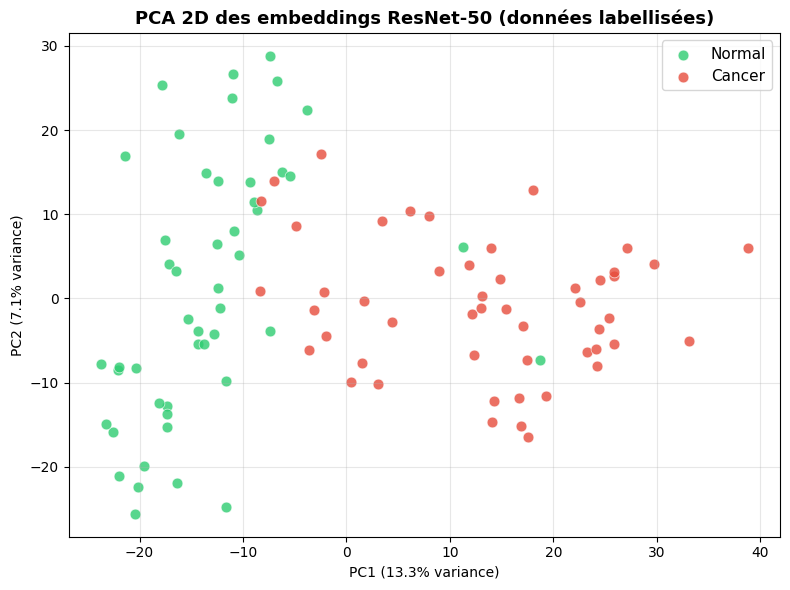

Variance expliquée PC1+PC2 : 20.4%
→ Si les classes sont séparables visuellement, le clustering aura de bonnes chances de fonctionner.


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
emb_labeled_scaled = scaler.fit_transform(embeddings_labeled)

pca_2d = PCA(n_components=2, random_state=42)
emb_2d = pca_2d.fit_transform(emb_labeled_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
colors = {0: "#2ECC71", 1: "#E74C3C"}
labels_names = {0: "Normal", 1: "Cancer"}

for label_int in [0, 1]:
    mask = labels_labeled == label_int
    ax.scatter(
        emb_2d[mask, 0],
        emb_2d[mask, 1],
        c=colors[label_int],
        label=labels_names[label_int],
        alpha=0.8,
        s=60,
        edgecolors="white",
        linewidth=0.5,
    )

ax.set_title(
    "PCA 2D des embeddings ResNet-50 (données labellisées)",
    fontsize=13,
    fontweight="bold",
)
ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0] * 100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1] * 100:.1f}% variance)")
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUTPUTS_DIR / "pca_2d_labeled.png"), bbox_inches="tight")
plt.show()

print(
    f"Variance expliquée PC1+PC2 : {sum(pca_2d.explained_variance_ratio_) * 100:.1f}%"
)
print(
    "→ Si les classes sont séparables visuellement, le clustering aura de bonnes chances de fonctionner."
)


### 2.6 Synthèse Partie 2

Ce notebook a produit les fondations du projet : des embeddings de qualité pour toutes les images. Le **Notebook 2** va exploiter ces vecteurs pour :

1. **Clustering non-supervisé** : identifier des groupes naturels et attribuer des _labels faibles_ aux 1 406 images non annotées.
2. **Apprentissage semi-supervisé** : entraîner et comparer un modèle supervisé vs semi-supervisé pour quantifier l'apport des données non labellisées.


In [15]:
print("SYNTHÈSE EXTRACTION DE FEATURES")
print("  Modèle          : ResNet-50 (pré-entraîné ImageNet)")
print("  Couches gelées  : OUI (extraction pure, pas de fine-tuning)")
print("  Dimension       : 2048D par image")
print("  Preprocessing   : 224×224 px, RGB, normalisation ImageNet")
print()
print(f"  embeddings_labeled.npy   : shape {embeddings_labeled.shape}")
print(f"  embeddings_unlabeled.npy : shape {embeddings_unlabeled.shape}")
print()
print("Prêt pour le Notebook 2 : Clustering + Semi-supervisé")


SYNTHÈSE EXTRACTION DE FEATURES
  Modèle          : ResNet-50 (pré-entraîné ImageNet)
  Couches gelées  : OUI (extraction pure, pas de fine-tuning)
  Dimension       : 2048D par image
  Preprocessing   : 224×224 px, RGB, normalisation ImageNet

  embeddings_labeled.npy   : shape (99, 2048)
  embeddings_unlabeled.npy : shape (1311, 2048)

Prêt pour le Notebook 2 : Clustering + Semi-supervisé
